# Enviroment Variables

In [28]:
import math

import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.nn import Sigmoid
from sklearn.datasets import make_moons, make_blobs
import random

RELATIVE_ERROR = 1e-12

# Utils

In [29]:
class Visualization :

    def __init__(self):
        self.n = 0;

    @staticmethod
    def make_scatter(x, y, c):
        plt.figure()

        plt.scatter(x, y, c=c)

        plt.title("Diagrama de Dipersión")
        plt.xlabel("Eje X")
        plt.ylabel("Eje Y")

        plt.tight_layout()

    @staticmethod
    def make_error_plot(history_error, title : str):
        plt.figure()

        plt.plot(history_error)
        plt.title(f"{title} - Gráfica de Error")
        plt.xlabel("Iteración")
        plt.ylabel("Error")

    @staticmethod
    def make_scatter_with_line(x, y, c, y_line, title : str):
        plt.figure()
        plt.scatter(x,y,c=c)

        plt.plot(x,y_line)

        plt.title(f"Diagrama de Disperción {title} con la superficie de decisión")
        plt.xlabel("Eje X")
        plt.ylabel("Eje Y")

    @staticmethod
    def show():
        plt.show()

    def save(self):
        plt.savefig(f"{self.n}.png")
        self.n += 1

visualization = Visualization()

class Counter:
    def __init__(self):
        self.n = 0

    def get(self):
        return self.n

    def increment(self):
        self.n += 1

counter = Counter()

class Table:
    """! The Table class
    Defines the functions used to generate, update and show a pandas dataframe
    """
    def __init__(self, data: pd.DataFrame, names : list[str]):
        """! The Table class initializer
        @param data The panda data frame
        @param names The names used to define the columns in the table

        @return An instance of the Table class initialized with a dataframe with the given columns names
        """

        # The dataframe of the table
        self.data = data

        # Initialize all the columns with the given names
        for name in names:
            self.data[name] = pd.Series(dtype=object)

    def add(self, row : int, column : str, value):
        """! Add a value in a specific column of the table
        @param row Row in the table
        @param column Column in the table
        @param value Value to add in the table
        """

        # Rounds float values for consistency
        if isinstance(value, float):
            value = round(value, 6)

        # Inserts or updates the value in the table
        self.data.loc[row, column] = value

    def show(self):
        """! Show the table
        """

        # Show the dataframe
        print(self.data)

    def generate_latex(self, index : bool, name : int):
        self.data.to_latex(f"{name}.tex", index=index)

# Perceptron Algorithm

In [30]:
class Perceptron:

    def forward(self, X : torch.Tensro, w : torch.Tensor):
        return torch.sign(X @ w)

    def gradient(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        perceptron_criteria = (X @ w) * t
        mask = (perceptron_criteria <= 0).squeeze()

        U = X[mask]
        t_U = t[mask]

        return (U * t_U).sum(dim=0).view(-1, 1)

    def error(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (t - self.forward(X, w)).abs().mean()

    def accuracy(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (self.forward(X, w) == t).float().mean()

    def train(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor, iterations : int, alpha : float):
        history_error = []
        for i in range(iterations):
            history_error.append(self.error(X,w,t).item())
            delta = self.gradient(X, w, t)
            w = w + alpha * delta

        return w, history_error

# Logistic Regression

In [31]:
class LogisticRegression:

    def __init__(self):
        self.sigmoid = Sigmoid()

    def forward(self, X : torch.Tensor, w : torch.Tensor):
        return self.sigmoid(X @ w)

    def gradient(self, X :torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        diff = (X * (t - self.forward(X, w))).sum(dim=0)
        return diff.view(-1, 1) / X.shape[0]

    def medium_absolute_error(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (t - self.forward(X, w)).abs().mean()

    def accuracy(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor):
        return (self.forward(X, w) == t).float().mean()

    def train(self, X : torch.Tensor, w : torch.Tensor, t : torch.Tensor, iterations : int, alpha : float):
        history_error = []
        for i in range(iterations):
            history_error.append(self.medium_absolute_error(X, w, t).item())
            delta = self.gradient(X, w, t)
            w = w + alpha * delta

        return w, history_error

# Unit tests: Forward

## Test 1 - Forward

In [32]:
def logistic_regression_forward_test_1():
    # objetivos
    X = torch.tensor([
        [1.0, 35.0, 50],
        [1.0, 40.0, 53],
        [1.0, 25.0, 80],
        [1.0, 28.0, 73]
    ])

    w = torch.tensor([
        [0.3],
        [0.2],
        [0.25]
    ])

    expected_product = torch.tensor([
            [19.8],
            [21.55],
            [25.3],
            [24.15]
    ])

    sigmoid = Sigmoid()
    logistic_regression = LogisticRegression()

    expected_result = sigmoid(expected_product)
    result = logistic_regression.forward(X, w)

    assert (expected_result-result).abs().max().item() < RELATIVE_ERROR

logistic_regression_forward_test_1()

# Generate Dataset

In [33]:
class DatasetGenerator:

    @staticmethod
    def generate_nonlinearly_separable(seed):
        X,Y = make_moons(noise=0.15, random_state=seed)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        Y_tensor = torch.tensor(Y, dtype=torch.float32)
        return X_tensor, Y_tensor

    @staticmethod
    def generate_linearly_separable(seed):
        X, Y = make_blobs(centers=2, random_state=seed, cluster_std=0.1)
        X_tensor = torch.tensor(X, dtype=torch.float32)
        Y_tensor = torch.tensor(Y, dtype=torch.float32)
        return X_tensor, Y_tensor

    @staticmethod
    def split(X : torch.Tensor, Y : torch.Tensor, ratio = 0.7):
        separated_X = X.split(int(X.shape[0]*ratio))
        separated_Y = Y.split(int(Y.shape[0]*ratio))
        return [separated_X[0], separated_Y[0]], [separated_X[1], separated_Y[1]]

# Logistic Regression Analysis

In [34]:
class LogisticRegressionAnalysis:

    def __init__(self):
        self.model = LogisticRegression()
        self.iterations = 100
        self.alpha = 1

    @staticmethod
    def transformData(data):
        return torch.cat((torch.ones(data.shape[0], 1), data), dim=1)

    def train(self,training_data: list[torch.Tensor]):
        data, labels = training_data
        data = self.transformData(data)
        w, history_error = self.model.train(data, torch.rand(3).view(-1, 1) , labels.view(-1, 1), self.iterations, self.alpha)
        return w, history_error

    @staticmethod
    def testData(name: str, test_data: list[torch.Tensor], w : torch.Tensor):
        M, t = test_data
        y_line = -(w[0] + w[1] * M[:,0]) / w[2]
        visualization.make_scatter_with_line(M[:,0], M[:,1],t, y_line, name)
        visualization.save()
        visualization.show()

    def make_table(self, table : Table, separable_errors : list[float], nonseparable_errors : list[float]):
        for i in range(self.iterations):
            table.add(i, "Linealmente separable", separable_errors[i])
            table.add(i, "No linealmente separable", nonseparable_errors[i])
            table.add(i, "Diferencia Absoluta", abs(separable_errors[i] - nonseparable_errors[i]))
            table.add(i, "Menor error", "Linealmente separable" if separable_errors[i] < nonseparable_errors[i] else "No linealmente separable" )

    @staticmethod
    def generate_data(seed : int, func):
        points, classification = func(seed)
        training_data, testing_data = DatasetGenerator.split(points,classification)
        return training_data, testing_data

    def run(self, seed : int):
        error_table = Table(pd.DataFrame(),["Linealmente separable", "No linealmente separable", "Diferencia Absoluta"])

        separable_training_data, separable_testing_data = self.generate_data(seed, DatasetGenerator.generate_linearly_separable)
        separable_w, separable_errors = self.train(separable_training_data)
        visualization.make_error_plot(separable_errors,"Linealmente separable")
        visualization.save()

        nonseparable_training_data, nonseparable_testing_data = self.generate_data(seed, DatasetGenerator.generate_nonlinearly_separable)
        nonseparable_w, nonseparable_errors = self.train(nonseparable_training_data)
        visualization.make_error_plot(nonseparable_errors,"No linealmente separable")
        visualization.save()

        self.make_table(error_table, separable_errors, nonseparable_errors)

        self.testData("Linealmente separable", separable_testing_data, separable_w)
        self.testData("No linealmente separable", nonseparable_testing_data, nonseparable_w)

        error_table.show()
        error_table.generate_latex(False, counter.get())
        counter.increment()

    def statistics(self, func):
        table = Table(pd.DataFrame(),["Promedio MAE(entrenamiento)", "Desviación estándar MAE(entrenamiento)", "MAE con datos de prueba"])
        error_list = torch.empty(0)
        std_list = torch.empty(0)

        for i in range(10):
            train_data, test_data = self.generate_data(random.randint(0,10000), func)
            w, error = self.train(train_data)
            mae_mean = torch.tensor(error).mean()
            mae_std = torch.tensor(error).std()
            mae = self.model.medium_absolute_error(self.transformData(test_data[0]), w, test_data[1].view(-1, 1))
            error_list = torch.cat((error_list, mae.unsqueeze(0)))
            std_list = torch.cat((std_list, mae_std.unsqueeze(0)))

            table.add(i, "Promedio MAE(entrenamiento)", mae_mean.item())
            table.add(i, "Desviación estándar MAE(entrenamiento)", mae_std.item())
            table.add(i, "MAE con datos de prueba", mae.item())
        table.show()
        table.generate_latex(True, counter.get())
        counter.increment()
        return error_list.mean().item(), std_list.mean().item(), error_list.min().item()

    def runMany(self):
        separable_mean_error, separable_mean_std, separable_min_error = self.statistics(DatasetGenerator.generate_linearly_separable)
        nonseparable_mean_error, nonseparable_mean_std, nonseparable_min_error = self.statistics(DatasetGenerator.generate_nonlinearly_separable)

        compare_table = Table(pd.DataFrame(),[" ","Linealmente Separable", "No linealmente Separable"])
        compare_table.add(0," ","Promedio de MAE")
        compare_table.add(1," ","Promedio de Desviación estándar")
        compare_table.add(2," ","Mínimo error MAE obtenido")
        compare_table.add(0,"Linealmente Separable",separable_mean_error)
        compare_table.add(0,"No linealmente Separable",nonseparable_mean_error)
        compare_table.add(1,"Linealmente Separable",separable_mean_std)
        compare_table.add(1,"No linealmente Separable",nonseparable_mean_std)
        compare_table.add(2,"Linealmente Separable", separable_min_error)
        compare_table.add(2,"No linealmente Separable", nonseparable_min_error)
        compare_table.show()
        compare_table.generate_latex(False, counter.get())
        counter.increment()


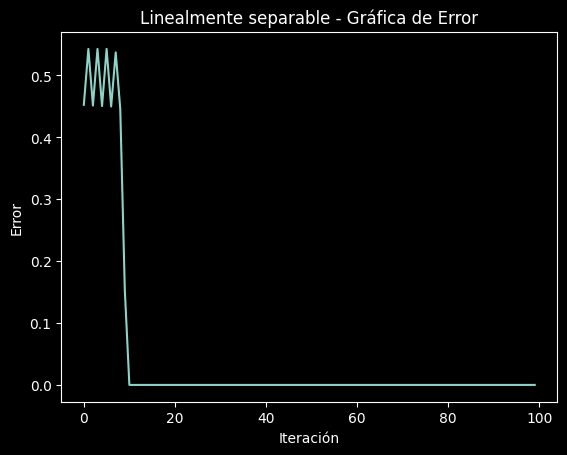

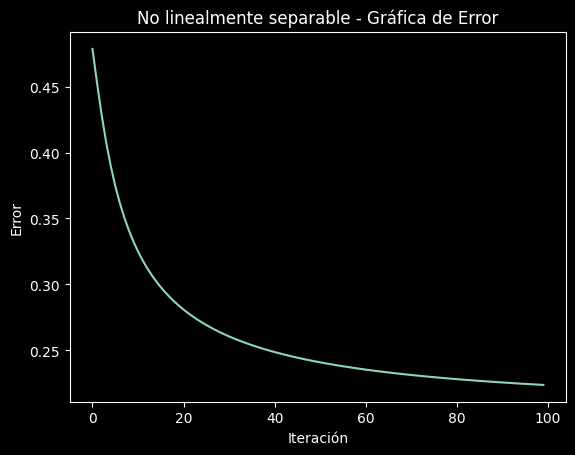

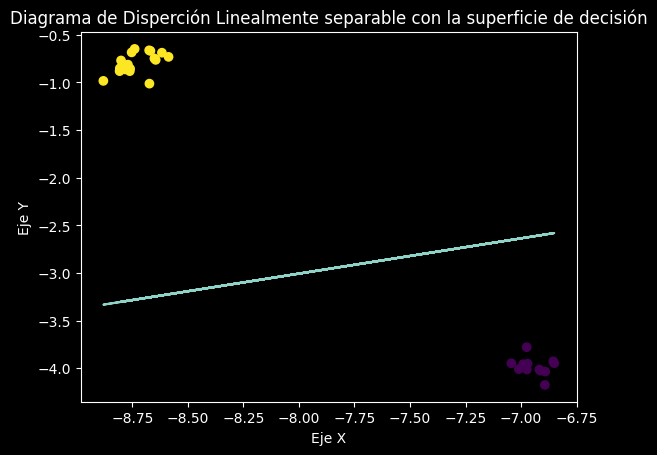

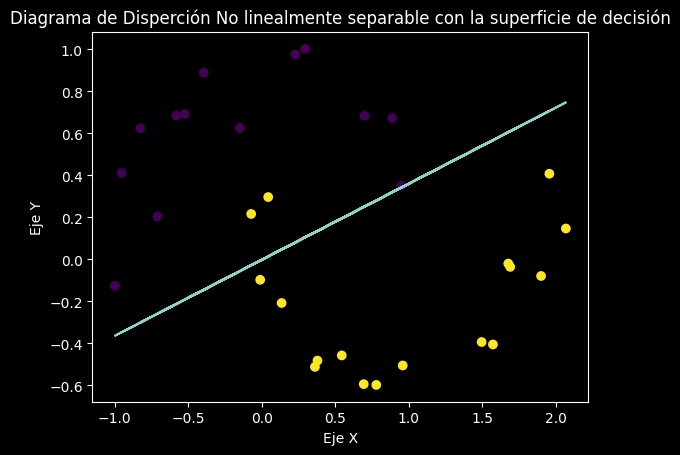

   Linealmente separable No linealmente separable Diferencia Absoluta  \
0               0.452543                 0.478667            0.026124   
1               0.542857                 0.453053            0.089804   
2               0.451366                 0.429034            0.022332   
3               0.542857                 0.408023            0.134834   
4               0.450538                 0.390107            0.060432   
..                   ...                      ...                 ...   
95              0.000012                 0.224512              0.2245   
96              0.000012                  0.22431            0.224298   
97              0.000012                 0.224111            0.224099   
98              0.000012                 0.223916            0.223904   
99              0.000012                 0.223725            0.223713   

                 Menor error  
0      Linealmente separable  
1   No linealmente separable  
2   No linealmente separable  

In [35]:
logistic_regression_analysis = LogisticRegressionAnalysis()
logistic_regression_analysis.run(777)

In [36]:
logistic_regression_analysis.runMany()

  Promedio MAE(entrenamiento) Desviación estándar MAE(entrenamiento)  \
0                    0.015375                               0.043664   
1                    0.028867                               0.055295   
2                    0.010037                               0.070613   
3                     0.04712                               0.135911   
4                     0.00054                               0.003952   
5                      0.0095                               0.095001   
6                     0.01275                               0.100301   
7                    0.026005                               0.109139   
8                    0.003393                               0.021087   
9                    0.004826                                0.04797   

  MAE con datos de prueba  
0                 0.00322  
1                0.009246  
2                     0.0  
3                0.000506  
4                0.000072  
5                     0.0  
6          

# Parte 2